In [106]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/1.csv", encoding="1251", sep=";")

for i in df:
    df.drop(inplace=True, columns="TimeStamp")
    break
print(df)

       Температура масла в магистрали общей откачки (поз. Тм)  \
0                                                 21.548        
1                                                 21.548        
2                                                 21.548        
3                                                 21.548        
4                                                 21.548        
...                                                  ...        
12654                                             43.561        
12655                                             43.561        
12656                                             43.561        
12657                                             43.561        
12658                                             43.561        

       Температура слива масла из опоры турбины (поз. Т606)  \
0                                                 28.160      
1                                                 28.160      
2                             

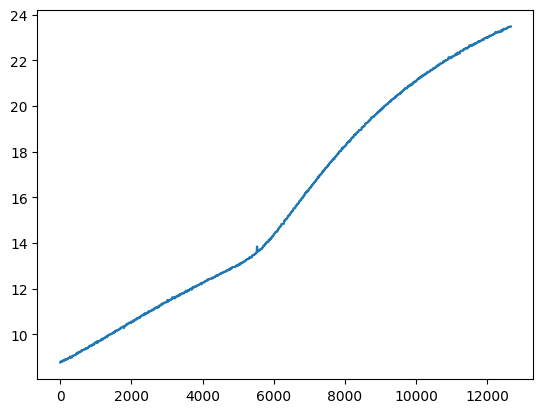

In [109]:

fig = plt.figure()
plt.plot(df["Температура топливного газа перед СК (перед расходомерным устройством) (поз. Ттг)"])
col = "Температура топливного газа перед СК (перед расходомерным устройством) (поз. Ттг)"
plt.show()

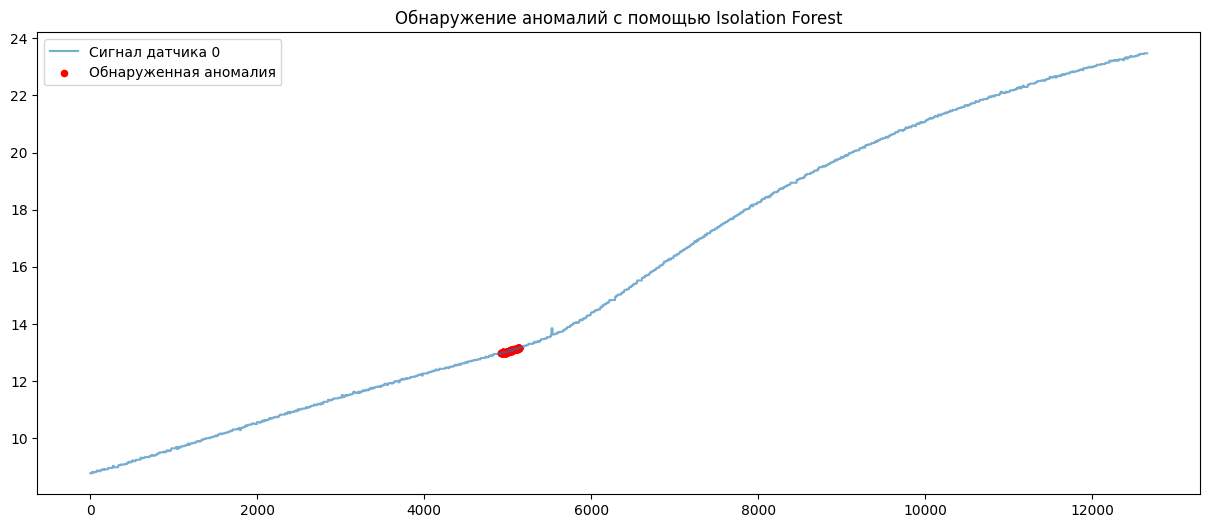

Количество найденных аномалий: 127
      Температура масла в магистрали общей откачки (поз. Тм)  \
4914                                             31.683        
4922                                             31.776        
4923                                             31.776        
4926                                             31.776        
4927                                             31.776        

      Температура слива масла из опоры турбины (поз. Т606)  \
4914                                             41.775      
4922                                             41.822      
4923                                             41.822      
4926                                             41.822      
4927                                             41.822      

      Температура масла на входе в двигатель за фильтром (поз. Т607)  \
4914                                             23.363                
4922                                             23.363        

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Генерация имитации ваших данных (24 датчика)
# np.random.seed(42)
# n_samples = 1000
# data = np.random.normal(loc=0, scale=1, size=(n_samples, 23))
#df = pd.DataFrame(data, columns=[f'Sensor_{i}' for i in range(24)])
# df = pd.read_csv("data/1.csv", encoding="1251", sep=";")

# 2. Искусственное внесение аномалий (для проверки модели)
# Внесем "шум" в интервале 600-650 и резкий выброс в 800
# df.iloc[600:650] += np.random.normal(loc=0, scale=5, size=(50, 23)) # Увеличение дисперсии (шум)
# df.iloc[800, :] += 10 # Резкий скачок (выброс)

# 3. Подготовка данных
# Важно: Isolation Forest требует масштабирования данных!
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 4. Инициализация и обучение модели
# contamination='auto' позволяет модели самой определить % аномалий
# Если вы знаете, что аномалий ~1%, ставьте contamination=0.01
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model.fit(df_scaled)

# 5. Прогнозирование
# -1 = аномалия, 1 = норма
predictions = model.predict(df_scaled)
scores = model.decision_function(df_scaled) # Степень "аномальности" (чем меньше, тем аномальнее)

# Добавляем результаты в DataFrame
df['Anomaly'] = predictions
df['Score'] = scores

# 6. Визуализация результатов (для одного датчика в качестве примера)
plt.figure(figsize=(15, 6))
# Исходный сигнал 0-го датчика
plt.plot(df.index, df[col], label='Сигнал датчика 0', alpha=0.6)

# Выделение аномалий
anomalies = df[df['Anomaly'] == -1]
plt.scatter(anomalies.index, anomalies[col], color='red', label='Обнаруженная аномалия', s=20)

plt.title('Обнаружение аномалий с помощью Isolation Forest')
plt.legend()
plt.show()

# Вывод строк, где найдены аномалии
print(f"Количество найденных аномалий: {len(anomalies)}")
print(anomalies.head())